C:\Users\bhara\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

✅ CNN trained on all 43 parts:
R² Score: 0.3671
Custom Accuracy: 91.19%


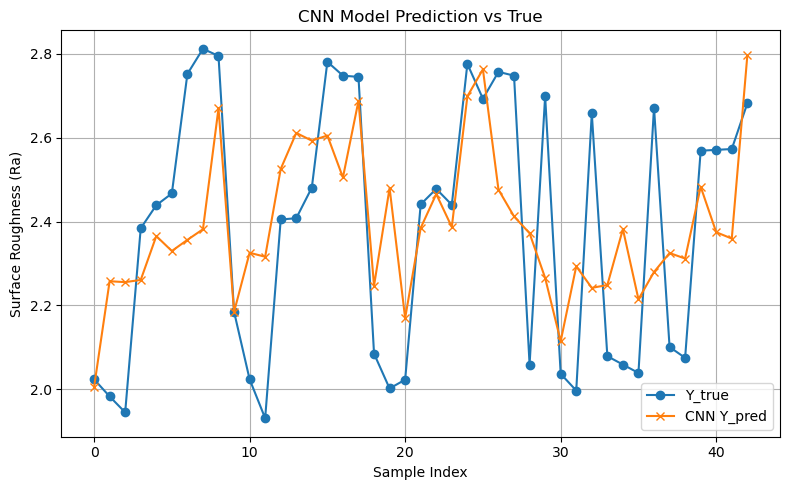


📁 Results saved to: Deep_Model_Results_43_Parts.xlsx


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM

# Load full dataset (43 parts)
df = pd.read_excel("Combined_43-Part_Dataset.xlsx")  # Combined 43-part data here
X = df.drop(columns=["Part.No", "Y_true"]).values
Y = df["Y_true"].values

# Normalize the input features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for CNN/LSTM models (samples, time_steps, channels)
X_seq = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

# Accuracy formula
def custom_accuracy(y_true, y_pred):
    return np.mean(1 - np.abs(y_true - y_pred) / np.abs(y_true))

# Build and train CNN or LSTM model
def train_full_model(model_type):
    model = Sequential()
    
    if model_type == "CNN":
        model.add(Conv1D(32, kernel_size=2, activation='relu', input_shape=(X_seq.shape[1], 1)))
        model.add(Flatten())
    elif model_type == "LSTM":
        model.add(LSTM(32, input_shape=(X_seq.shape[1], 1)))
    
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_seq, Y, epochs=300, batch_size=8, verbose=0)
    
    # Predict and evaluate
    Y_pred = model.predict(X_seq).flatten()
    acc = custom_accuracy(Y, Y_pred)
    r2 = r2_score(Y, Y_pred)
    
    print(f"\n✅ {model_type} trained on all 43 parts:")
    print(f"R² Score: {r2:.4f}")
    print(f"Custom Accuracy: {acc * 100:.2f}%")

    # Plotting predictions vs ground truth
    plt.figure(figsize=(8, 5))
    plt.plot(Y, label="Y_true", marker='o')
    plt.plot(Y_pred, label=f"{model_type} Y_pred", marker='x')
    plt.title(f"{model_type} Model Prediction vs True")
    plt.xlabel("Sample Index")
    plt.ylabel("Surface Roughness (Ra)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return Y_pred

# Train and get predictions
y_pred_cnn = train_full_model("CNN")


# Save all predictions along with inputs to Excel
results_df = df.copy()
results_df["Y_pred_CNN"] = y_pred_cnn

results_df.index = [f"Part {i+1}" for i in range(len(Y))]

# Output file path
output_file = "Deep_Model_Results_43_Parts.xlsx"
results_df.to_excel(output_file)

print(f"\n📁 Results saved to: {output_file}")


C:\Users\bhara\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step

✅ CNN Evaluation on Test Set (Random Split):
R² Score: -0.6883
Custom Accuracy: 88.72%


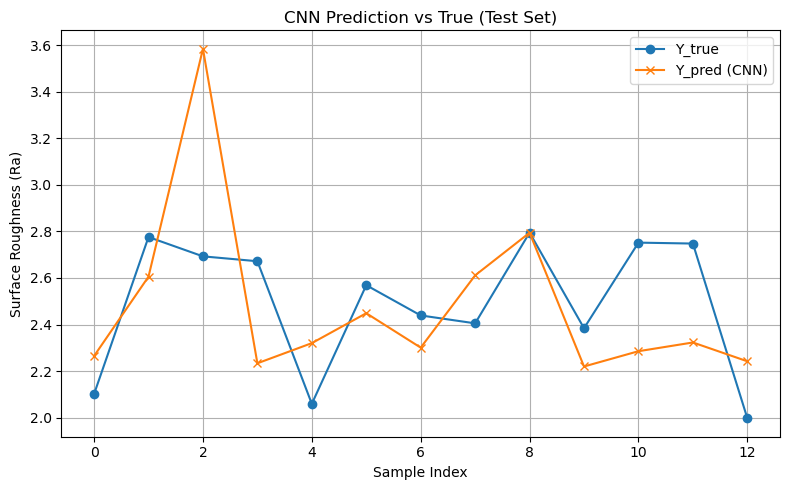


📁 Results saved to: CNN_Test_Predictions_Split.xlsx


In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout

# Load combined dataset (43 parts)
df = pd.read_excel("Combined_43-Part_Dataset.xlsx")

# Drop non-numeric column and separate features/target
X = df.drop(columns=["Part.No", "Y_true"]).values
Y = df["Y_true"].values

# ✅ Automatically split into train (70%) and test (30%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Normalize
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for CNN
X_train_seq = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_seq = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# Custom accuracy
def custom_accuracy(y_true, y_pred):
    return np.mean(1 - np.abs(y_true - y_pred) / np.abs(y_true)) * 100

# Build CNN model
model = Sequential([
    Conv1D(32, kernel_size=2, activation='relu', input_shape=(X_train_seq.shape[1], 1)),
    Dropout(0.2),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train_seq, Y_train, epochs=300, batch_size=8, verbose=0)

# Predict on test
Y_pred = model.predict(X_test_seq).flatten()

# Evaluate
r2 = r2_score(Y_test, Y_pred)
acc = custom_accuracy(Y_test, Y_pred)

print("\n✅ CNN Evaluation on Test Set (Random Split):")
print(f"R² Score: {r2:.4f}")
print(f"Custom Accuracy: {acc:.2f}%")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(Y_test, label="Y_true", marker='o')
plt.plot(Y_pred, label="Y_pred (CNN)", marker='x')
plt.title("CNN Prediction vs True (Test Set)")
plt.xlabel("Sample Index")
plt.ylabel("Surface Roughness (Ra)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Save to Excel
results_df = pd.DataFrame({
    "Y_true": Y_test,
    "Y_pred_CNN": Y_pred
})
results_df.index = [f"Part {i+1}" for i in range(len(Y_test))]
results_df.to_excel("CNN_Test_Predictions_Split.xlsx")

print("\n📁 Results saved to: CNN_Test_Predictions_Split.xlsx")
